# Loan Approval Prediction

## 1. Problem Definition

### Business objective

The objective is to build a machine-learning model that predicts whether a loan
application is likely to be approved based on the applicant's financial and
demographic information.

The model is intended as a decision-support and educational tool. It should not
make autonomous lending decisions.

### Machine-learning task

This is a supervised binary-classification problem.

- Target column: `Loan_Status`
- Positive class: `Y` — loan approved
- Negative class: `N` — loan not approved
- Unit of observation: one loan application

### Evaluation priorities

Because the target classes may be imbalanced, accuracy alone will not be used.

The model will be evaluated using:

1. Macro F1-score as the primary model-comparison metric
2. Recall and precision for both approval classes
3. ROC-AUC
4. Confusion matrix
5. Accuracy as a supporting metric

### Error considerations

- False approval: the model predicts approval for an application historically
  recorded as not approved.
- False rejection: the model predicts rejection for an application historically
  recorded as approved.

Both errors will be reported separately rather than hidden inside overall
accuracy.

### Important limitation

`Loan_Status` records historical approval decisions. It does not indicate whether
a borrower eventually repaid or defaulted on the loan. Therefore, this model
learns historical approval patterns—not true credit risk or repayment ability.

Demographic variables may also reproduce historical bias. Fairness checks will
be performed before considering any practical use.


In [1]:
import sys
from pathlib import Path
import json
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning libraries
import joblib
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import optuna
import sklearn



import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    GridSearchCV,
    cross_validate,
    StratifiedKFold,
    train_test_split
)

#Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)


warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_TRIALS = 20

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Finance.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"Python:       {platform.python_version()}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"LightGBM:     {lgb.__version__}")
print(f"Optuna:       {optuna.__version__}")
print(f"MLflow:       {mlflow.__version__}")
print(f"Data path:    {DATA_PATH}")

Python:       3.11.15
scikit-learn: 1.9.0
LightGBM:     4.7.0
Optuna:       4.9.0
MLflow:       3.14.0
Data path:    c:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Loan Approval Predcitor (PJ 5)\loan_approval_predictor\data\raw\Finance.csv


# Data Validation

In [ ]:
df_raw=pd.read_csv(DATA_PATH)

In [4]:
df_raw.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Dataset shape: 614 rows × 13 columns


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
schema_summary = pd.DataFrame({
    "data_type": df_raw.dtypes.astype(str),
    "non_missing": df_raw.notna().sum(),
    "missing": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean().mul(100).round(2),
    "unique_values": df_raw.nunique(dropna=True),
})

schema_summary.index.name = "column"
display(schema_summary)

,data_type,non_missing,missing,missing_percent,unique_values
column,,,,,
Loan_ID,object,614,0,0.00,614
Gender,object,601,13,2.12,2
Married,object,611,3,0.49,2
Dependents,object,599,15,2.44,4
Education,object,614,0,0.00,2
Self_Employed,object,582,32,5.21,2
ApplicantIncome,int64,614,0,0.00,505
CoapplicantIncome,float64,614,0,0.00,287
LoanAmount,float64,592,22,3.58,203


In [11]:
df_raw.describe(include="all")

column,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [12]:
TARGET = "Loan_Status"
ID_COLUMN = "Loan_ID"

EXPECTED_COLUMNS = {
    "Loan_ID",
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area",
    "Loan_Status",
}

missing_columns = sorted(EXPECTED_COLUMNS - set(df_raw.columns))
unexpected_columns = sorted(set(df_raw.columns) - EXPECTED_COLUMNS)

print(f"Missing columns: {missing_columns}")
print(f"Unexpected columns: {unexpected_columns}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print(f"Duplicate Loan IDs: {df_raw[ID_COLUMN].duplicated().sum()}")
print(f"Missing target values: {df_raw[TARGET].isna().sum()}")
print(f"Target values: {sorted(df_raw[TARGET].dropna().unique())}")

Missing columns: []
Unexpected columns: []
Duplicate rows: 0
Duplicate Loan IDs: 0
Missing target values: 0
Target values: ['N', 'Y']


# 4. Data-Quality Audit and Initial Exploration

This section examines missing values, duplicates, target balance, category
consistency, numerical distributions, and potential outliers.

No preprocessing decisions are applied to the raw dataset at this stage.

## 4.1 Check Data quality

In [13]:
quality_ckecks=pd.Series({
    "rows":len(df_raw),
    "columns":df_raw.shape[1],
    "Completely_empty_rows":df_raw.isna().all(axis=1).sum(),
    "duplicate_rows":df_raw.duplicated().sum(),
    "duplicate_Loan_IDs":df_raw[ID_COLUMN].duplicated().sum(),
    "missing_loan_id":df_raw[ID_COLUMN].isna().sum(),
    "missing_target_values":df_raw[TARGET].isna().sum(),
    "negative_applicant_income": (
        df_raw["ApplicantIncome"].dropna() < 0
    ).sum(),
    "negative_coapplicant_income": (
        df_raw["CoapplicantIncome"].dropna() < 0
    ).sum(),
    "non_positive_loan_amount": (
        df_raw["LoanAmount"].dropna() <= 0
    ).sum(),
    "non_positive_loan_term": (
        df_raw["Loan_Amount_Term"].dropna() <= 0
    ).sum(),
    "invalid_credit_history": (
        ~df_raw["Credit_History"].dropna().isin([0, 1])
    ).sum()
})

display(quality_ckecks.to_frame(name="value"))

,value
rows,614
columns,13
Completely_empty_rows,0
duplicate_rows,0
duplicate_Loan_IDs,0
missing_loan_id,0
missing_target_values,0
negative_applicant_income,0
negative_coapplicant_income,0
non_positive_loan_amount,0


## 4.2 Examine Missing Value

In [16]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df_raw.isna().sum(),
        "missing_percent": df_raw.isna().mean().mul(100),
    })
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

,missing_count,missing_percent
column,,
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


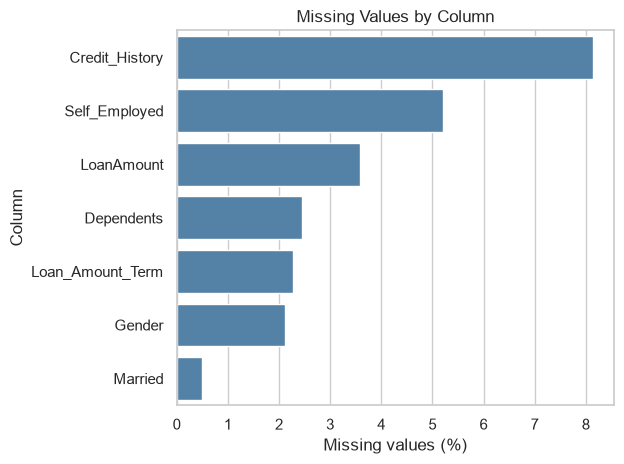

In [21]:
# Visualize missing values
# Prepare explicitly named plotting data
missing_plot_data = (
    missing_summary
    .rename_axis("column")
    .reset_index()
)

if not missing_plot_data.empty:
    ax = sns.barplot(
        data=missing_plot_data,
        x="missing_percent",
        y="column",
        color="steelblue",
    )

    ax.set(
        title="Missing Values by Column",
        xlabel="Missing values (%)",
        ylabel="Column",
    )

    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

## 4.3 Examine the Target Distribution


In [22]:
target_summary = (
    df_raw[TARGET]
    .value_counts(dropna=False)
    .rename_axis("loan_status")
    .to_frame("count")
)

target_summary["percent"] = (
    target_summary["count"]
    .div(len(df_raw))
    .mul(100)
)

display(target_summary)

,count,percent
loan_status,,
Y,422,68.729642
N,192,31.270358


## 4.4.1 Categorical EDA

In [24]:
categorical_eda_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area",
    "Loan_Amount_Term",
]

In [25]:
categorical_summaries = []

for column in categorical_eda_columns:
    # Convert to strings temporarily for display and preserve missing values
    display_values = (
        df_raw[column]
        .astype("string")
        .fillna("Missing")
    )

    column_summary = (
        display_values
        .value_counts(dropna=False)
        .rename_axis("category")
        .reset_index(name="count")
    )

    column_summary["percent"] = (
        column_summary["count"]
        .div(len(df_raw))
        .mul(100)
        .round(2)
    )

    column_summary.insert(0, "column", column)
    categorical_summaries.append(column_summary)

categorical_distribution = pd.concat(
    categorical_summaries,
    ignore_index=True,
)

display(categorical_distribution)

,column,category,count,percent
0,Gender,Male,489,79.64
1,Gender,Female,112,18.24
2,Gender,Missing,13,2.12
3,Married,Yes,398,64.82
4,Married,No,213,34.69
5,Married,Missing,3,0.49
6,Dependents,0,345,56.19
7,Dependents,1,102,16.61
8,Dependents,2,101,16.45
9,Dependents,3+,51,8.31


In [26]:
for column in categorical_eda_columns:
    print(f"\n{column}")
    
    display(
        categorical_distribution.loc[
            categorical_distribution["column"].eq(column)
        ]
    )


Gender


,column,category,count,percent
0,Gender,Male,489,79.64
1,Gender,Female,112,18.24
2,Gender,Missing,13,2.12



Married


,column,category,count,percent
3,Married,Yes,398,64.82
4,Married,No,213,34.69
5,Married,Missing,3,0.49



Dependents


...

,column,category,count,percent
16,Credit_History,1.0,475,77.36
17,Credit_History,0.0,89,14.5
18,Credit_History,Missing,50,8.14



Property_Area


,column,category,count,percent
19,Property_Area,Semiurban,233,37.95
20,Property_Area,Urban,202,32.9
21,Property_Area,Rural,179,29.15



Loan_Amount_Term


,column,category,count,percent
22,Loan_Amount_Term,360.0,512,83.39
23,Loan_Amount_Term,180.0,44,7.17
24,Loan_Amount_Term,480.0,15,2.44
25,Loan_Amount_Term,Missing,14,2.28
26,Loan_Amount_Term,300.0,13,2.12
27,Loan_Amount_Term,84.0,4,0.65
28,Loan_Amount_Term,240.0,4,0.65
29,Loan_Amount_Term,120.0,3,0.49
30,Loan_Amount_Term,60.0,2,0.33
31,Loan_Amount_Term,36.0,2,0.33


In [29]:
TARGET = "Loan_Status"

POSITIVE_LABEL = "Y"  # Approved
NEGATIVE_LABEL = "N"  # Rejected

In [30]:
categorical_summaries = []

for column in categorical_eda_columns:
    category_values = (
        df_raw[column]
        .astype("string")
        .fillna("Missing")
        .rename("category")
    )

    target_values = (
        df_raw[TARGET]
        .astype("string")
        .rename(TARGET)
    )

    # Count approved and rejected applications per category
    outcome_counts = pd.crosstab(
        category_values,
        target_values,
        dropna=False,
    )

    # Ensure both target columns exist
    outcome_counts = outcome_counts.reindex(
        columns=[NEGATIVE_LABEL, POSITIVE_LABEL],
        fill_value=0,
    )

    column_summary = (
        outcome_counts
        .rename(columns={
            NEGATIVE_LABEL: "rejected_count",
            POSITIVE_LABEL: "approved_count",
        })
        .reset_index()
    )

    column_summary["total_count"] = (
        column_summary["rejected_count"]
        + column_summary["approved_count"]
    )

    column_summary["dataset_percent"] = (
        column_summary["total_count"]
        .div(len(df_raw))
        .mul(100)
        .round(2)
    )

    column_summary["approval_rate"] = (
        column_summary["approved_count"]
        .div(column_summary["total_count"])
        .mul(100)
        .round(2)
    )

    column_summary["rejection_rate"] = (
        column_summary["rejected_count"]
        .div(column_summary["total_count"])
        .mul(100)
        .round(2)
    )

    column_summary.insert(0, "column", column)

    column_summary = column_summary.sort_values(
        "total_count",
        ascending=False,
    )

    categorical_summaries.append(column_summary)

categorical_distribution = pd.concat(
    categorical_summaries,
    ignore_index=True,
)

display(categorical_distribution)

Loan_Status,column,category,rejected_count,approved_count,total_count,dataset_percent,approval_rate,rejection_rate
0,Gender,Male,150,339,489,79.64,69.33,30.67
1,Gender,Female,37,75,112,18.24,66.96,33.04
2,Gender,Missing,5,8,13,2.12,61.54,38.46
3,Married,Yes,113,285,398,64.82,71.61,28.39
4,Married,No,79,134,213,34.69,62.91,37.09
5,Married,Missing,0,3,3,0.49,100.00,0.00
6,Dependents,0,107,238,345,56.19,68.99,31.01
7,Dependents,1,36,66,102,16.61,64.71,35.29
8,Dependents,2,25,76,101,16.45,75.25,24.75
9,Dependents,3+,18,33,51,8.31,64.71,35.29


## 4.6 Examine Numerical Distribution

In [31]:
continuous_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
]

numeric_summary = df_raw[continuous_columns].describe().T
numeric_summary["median"] = df_raw[continuous_columns].median()
numeric_summary["skewness"] = df_raw[continuous_columns].skew()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness
column,,,,,,,,,,
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0,3812.5,6.539513
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0,1188.5,7.491531
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0,128.0,2.677552
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0,360.0,-2.362414


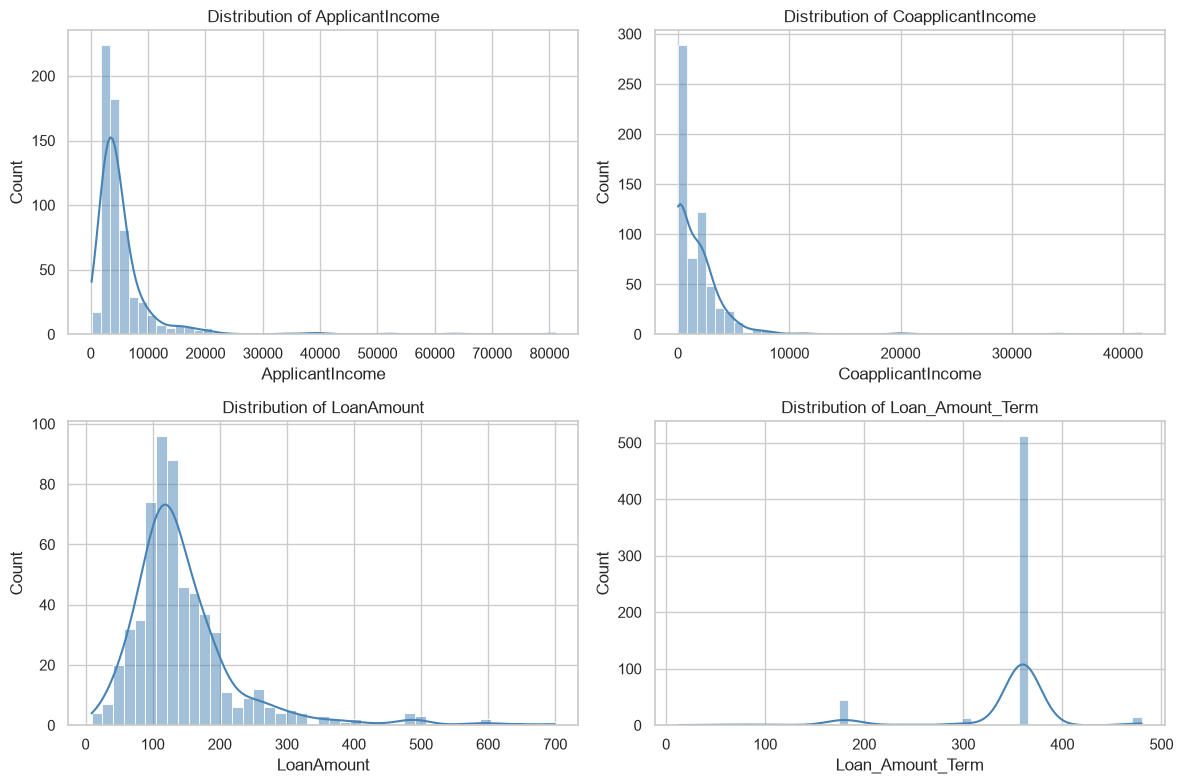

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for column, ax in zip(continuous_columns, axes.flat):
    sns.histplot(
        data=df_raw,
        x=column,
        kde=True,
        ax=ax,
        color="steelblue",
    )
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

## 4.6 Identify Potential Outlier

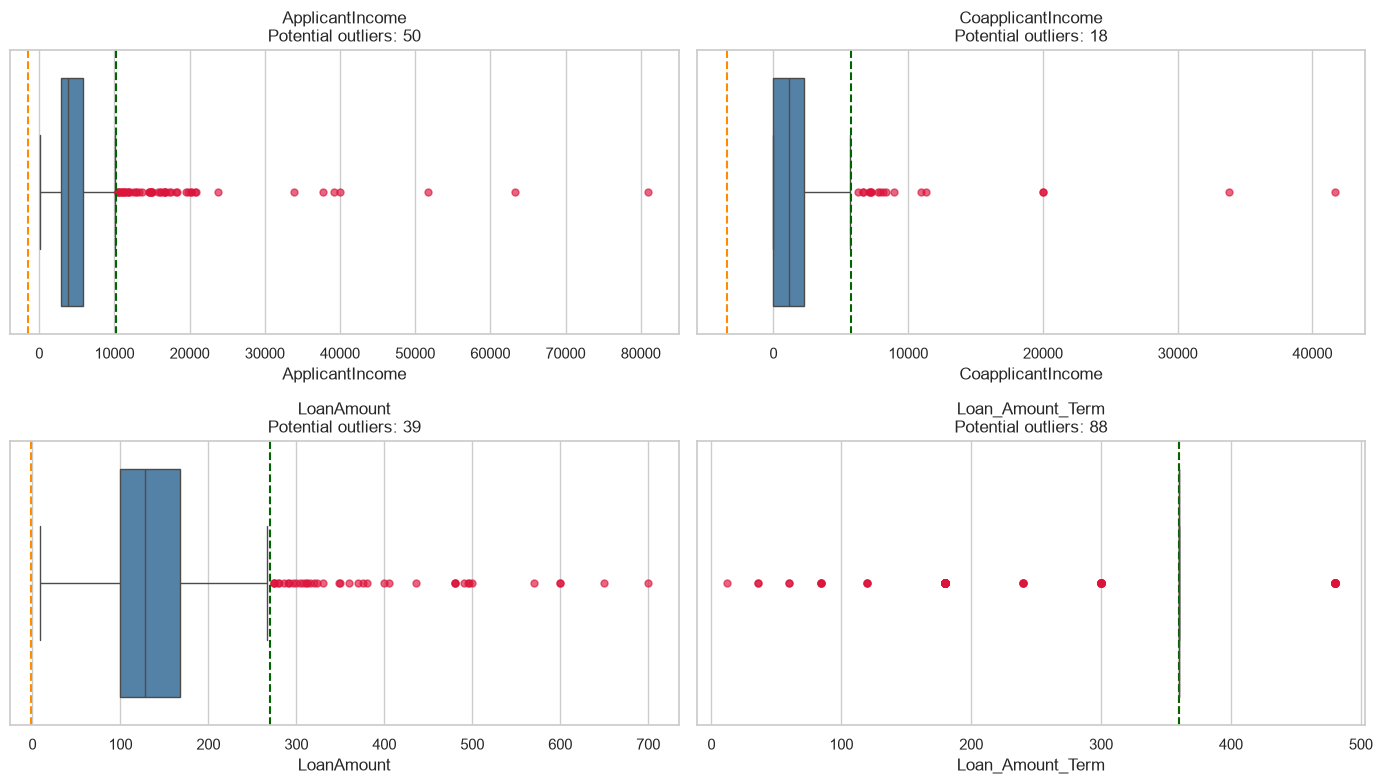

In [35]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
)

axes = axes.flatten()

outlier_style = {
    "marker": "o",
    "markerfacecolor": "crimson",
    "markeredgecolor": "crimson",
    "markersize": 5,
    "alpha": 0.65,
}

for ax, column in zip(axes, continuous_columns):
    values = df_raw[column].dropna()

    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr = third_quartile - first_quartile

    lower_bound = first_quartile - (1.5 * iqr)
    upper_bound = third_quartile + (1.5 * iqr)

    outlier_count = (
        (values < lower_bound) |
        (values > upper_bound)
    ).sum()

    sns.boxplot(
        data=df_raw,
        x=column,
        ax=ax,
        color="steelblue",
        showfliers=True,
        flierprops=outlier_style,
    )

    # Display the calculated IQR boundaries
    ax.axvline(
        lower_bound,
        color="darkorange",
        linestyle="--",
        linewidth=1.5,
        label="Lower IQR boundary",
    )

    ax.axvline(
        upper_bound,
        color="darkgreen",
        linestyle="--",
        linewidth=1.5,
        label="Upper IQR boundary",
    )

    ax.set_title(
        f"{column}\nPotential outliers: {outlier_count}"
    )
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

In [34]:
outlier_summary = calculate_iqr_outliers(
    df_raw,
    continuous_columns,
)

display(outlier_summary)

,column,lower_bound,upper_bound,potential_outliers,outlier_percent
0,ApplicantIncome,-1498.750,10171.250,50,8.143322
1,CoapplicantIncome,-3445.875,5743.125,18,2.931596
2,LoanAmount,-2.000,270.000,39,6.587838
3,Loan_Amount_Term,360.000,360.000,88,14.666667


# 5. Stratified Train-Test Split

A stratified holdout set is created before preprocessing. Stratification preserves
the approval/rejection proportions in both datasets.

The test set will remain untouched during EDA, preprocessing decisions, model
comparison, hyperparameter tuning, and threshold selection.